Leiden implementation

In [1]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


In [2]:
%pip install cdlib python-igraph leidenalg networkx


Note: you may need to restart the kernel to use updated packages.


In [2]:
import cdlib
import igraph
import leidenalg

print("cdlib", cdlib.__version__)
print("igraph", igraph.__version__)


cdlib 0.4.0
igraph 1.0.0


In [3]:
from cdlib.benchmark import LFR
from cdlib import algorithms, evaluation

G,coms = LFR(
    n=500,
    tau1=3,
    tau2=2.0,          # un po' più grande → community meno estremamente sbilanciate
    mu=0.1,
    average_degree=5,  # grado medio un po' più basso
    min_community=20,  # finestra community più larga
    tol=1e-5,          # più tolleranza
    max_iters=1000,    # più tentativi per trovare una partizione valida
    seed=42
)

print(G)                 # questo è un grafo NetworkX
gt_coms = coms.communities        # queste sono le community ground truth
print(coms.communities)
print("Numero di community ground truth:", len(gt_coms))

Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'bayanpy', 'infomap', 'graph_tool'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'infomap'}
Graph with 500 nodes and 1072 edges
[[256, 6, 393, 138, 140, 396, 19, 404, 277, 24, 414, 163, 164, 423, 167, 40, 298, 44, 173, 46, 48, 432, 50, 435, 307, 196, 458, 331, 205, 82, 212, 475, 224, 481, 228, 232, 116, 121, 250], [0, 131, 387, 5, 255, 135, 269, 144, 147, 150, 425, 42, 302, 49, 184, 59, 60, 454, 74, 462, 206, 465, 209, 469, 348, 222, 351, 99, 107, 499, 376, 249, 252, 127], [8, 394, 266, 141, 399, 15, 401, 146, 17, 278, 151, 168, 41, 170, 172, 428, 306, 313, 66, 453, 327, 328, 73, 332, 211, 83, 490, 491, 364, 493, 363, 111, 374, 118], [398, 273, 21, 406, 22, 408, 410, 413, 160, 32, 291, 420, 297, 43, 304, 433, 3

In [4]:
from cdlib import algorithms, evaluation

# 1) Esegui Leiden sul grafo G
leiden_coms = algorithms.leiden(G)

print("Comunità trovate da Leiden:", len(leiden_coms.communities))
print("Esempio prime 3 community trovate:")
for i, c in enumerate(leiden_coms.communities[:3]):
    print(f"Community {i}: {len(c)} nodi")


Comunità trovate da Leiden: 19
Esempio prime 3 community trovate:
Community 0: 39 nodi
Community 1: 34 nodi
Community 2: 34 nodi


In [5]:
# coms = ground truth (oggetto Clustering)
# leiden_coms = partizione trovata da Leiden

nmi = evaluation.normalized_mutual_information(leiden_coms, coms)
ari = evaluation.adjusted_rand_index(leiden_coms, coms)
mod = evaluation.newman_girvan_modularity(G, leiden_coms)

print("NMI:", nmi.score)
print("ARI:", ari.score)
print("Modularità (Leiden):", mod.score)


NMI: 0.995686055084489
ARI: 0.9948206924394132
Modularità (Leiden): 0.871798597961684


VISUALIZZAZIONE COMUNITÀ

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

# usa il grafo G che hai già generato
pos = nx.spring_layout(G, seed=42)  # layout force-directed

Communities di Ground Truth generate da LFR

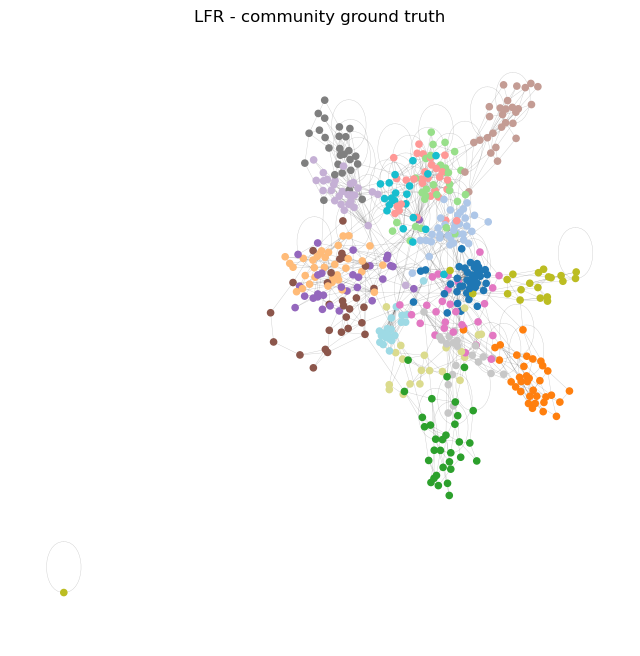

In [7]:
# Crea un dizionario nodo -> id_community ground truth
node_to_comm_gt = {}

for cid, community in enumerate(coms.communities):
    for node in community:
        node_to_comm_gt[node] = cid

# Lista dei colori per ogni nodo nell’ordine di G.nodes()
colors_gt = [node_to_comm_gt[node] for node in G.nodes()]

plt.figure(figsize=(8, 8))
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=20,
    node_color=colors_gt,
    cmap=plt.cm.tab20
)
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2,
    width=0.3
)
plt.title("LFR - community ground truth")
plt.axis("off")
plt.show()


Visualizzazione comunità trovate da Leiden

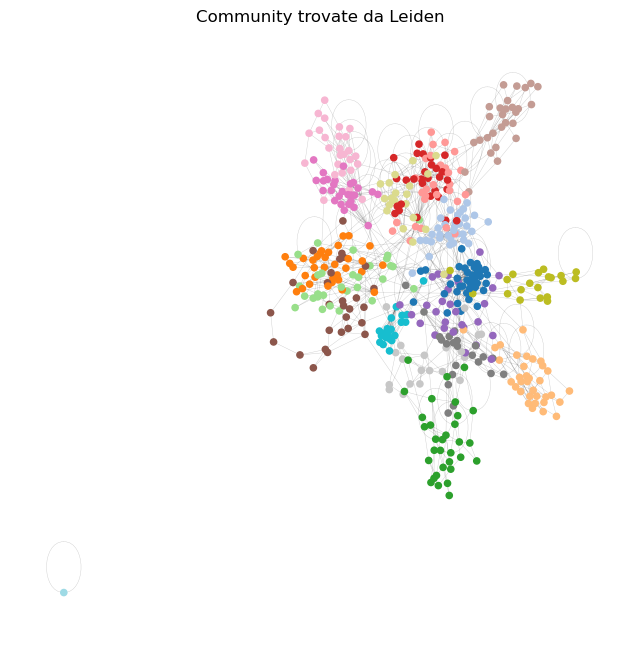

In [8]:
# Crea un dizionario nodo -> id_community Leiden
node_to_comm_leiden = {}

for cid, community in enumerate(leiden_coms.communities):
    for node in community:
        node_to_comm_leiden[node] = cid

colors_leiden = [node_to_comm_leiden[node] for node in G.nodes()]

plt.figure(figsize=(8, 8))
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=20,
    node_color=colors_leiden,
    cmap=plt.cm.tab20
)
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2,
    width=0.3
)
plt.title("Community trovate da Leiden")
plt.axis("off")
plt.show()


Comunità a confronto tra i due algoritmi

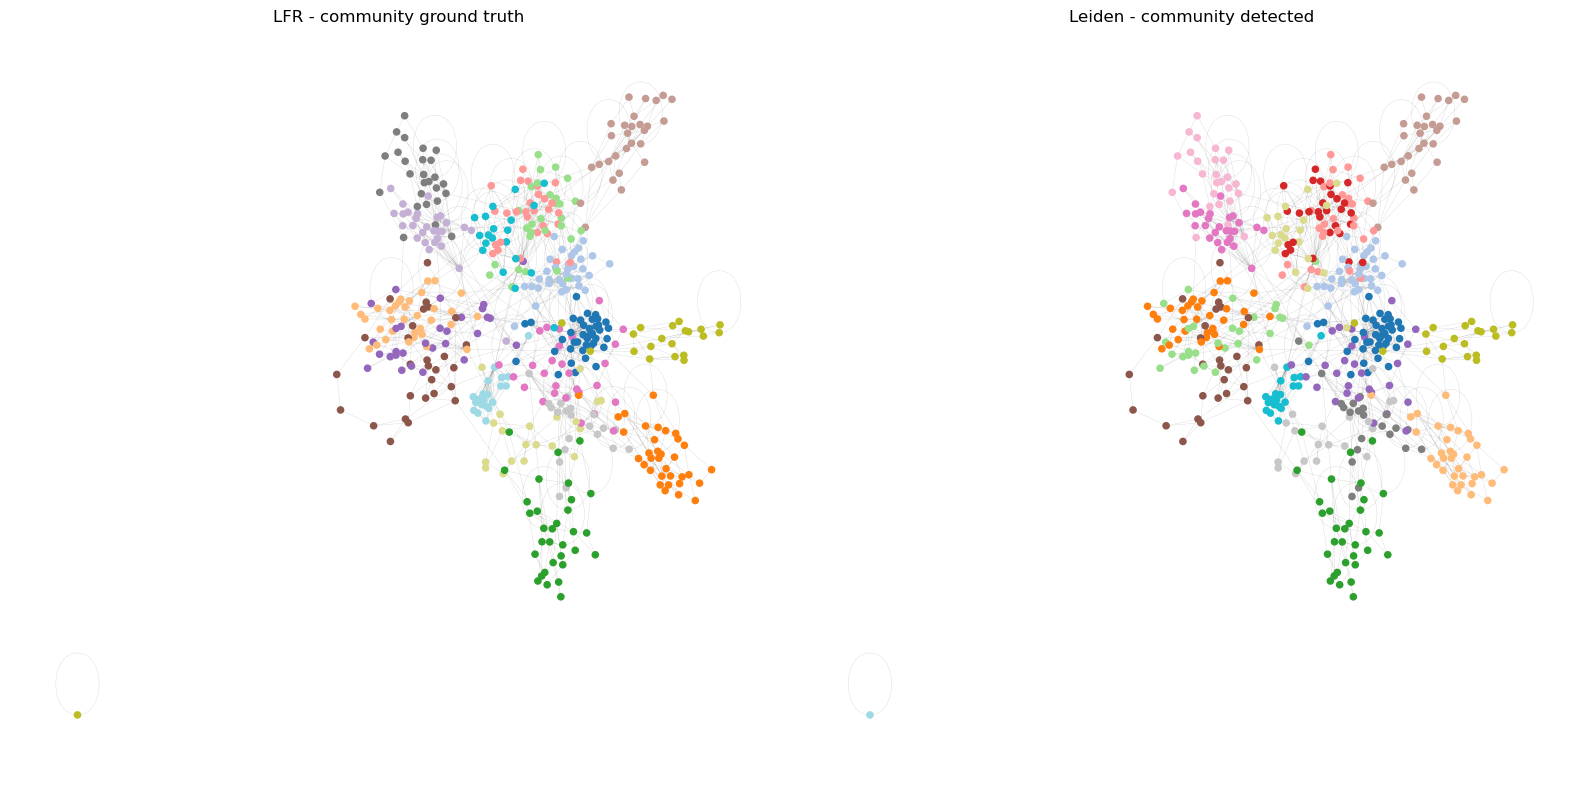

In [9]:
import matplotlib.pyplot as plt
import networkx as nx

# --- Se non esiste già il layout ---
pos = nx.spring_layout(G, seed=42)

# --- Ground truth colori ---
node_to_comm_gt = {}
for cid, community in enumerate(coms.communities):
    for node in community:
        node_to_comm_gt[node] = cid
colors_gt = [node_to_comm_gt[node] for node in G.nodes()]

# --- Leiden colori ---
node_to_comm_leiden = {}
for cid, community in enumerate(leiden_coms.communities):
    for node in community:
        node_to_comm_leiden[node] = cid
colors_leiden = [node_to_comm_leiden[node] for node in G.nodes()]

# --- Plot side by side ---
plt.figure(figsize=(16, 8))

# ------ Plot 1: Ground truth ------
plt.subplot(1, 2, 1)
nx.draw_networkx_nodes(
    G, pos,
    node_size=20,
    node_color=colors_gt,
    cmap=plt.cm.tab20
)
nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.3)
plt.title("LFR - community ground truth")
plt.axis("off")

# ------ Plot 2: Leiden ------
plt.subplot(1, 2, 2)
nx.draw_networkx_nodes(
    G, pos,
    node_size=20,
    node_color=colors_leiden,
    cmap=plt.cm.tab20
)
nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.3)
plt.title("Leiden - community detected")
plt.axis("off")

plt.tight_layout()
plt.show()


Vari parametri di LFR per vedere come cambia il community detection

In [ ]:
import networkx as nx
import pandas as pd
from cdlib.benchmark import LFR
from cdlib import algorithms, evaluation

def run_lfr_experiment(
    mu,
    tau2,
    n=500,
    tau1=3,
    average_degree=5,
    min_community=20,
    base_seed=42,
    max_tentativi=1000,
):
    """
    Genera un grafo LFR con certi parametri, esegue Leiden,
    calcola NMI/ARI/modularità e ritorna un dizionario con i risultati.
    Prova più seed se LFR lancia ExceededMaxIterations.
    """
    for offset in range(max_tentativi):
        seed = base_seed + offset
        try:
            G, coms = LFR(
                n=n,
                tau1=tau1,
                tau2=tau2,
                mu=mu,
                average_degree=average_degree,
                min_community=min_community,
                seed=seed,
            )

            leiden_coms = algorithms.leiden(G)

            nmi = evaluation.normalized_mutual_information(leiden_coms, coms).score
            ari = evaluation.adjusted_rand_index(leiden_coms, coms).score
            mod = evaluation.newman_girvan_modularity(G, leiden_coms).score

            return {
                "mu": mu,
                "tau2": tau2,
                "seed": seed,
                "n_nodes": G.number_of_nodes(),
                "n_edges": G.number_of_edges(),
                "n_coms_gt": len(coms.communities),
                "n_coms_leiden": len(leiden_coms.communities),
                "NMI": nmi,
                "ARI": ari,
                "modularity": mod,
            }

        except nx.ExceededMaxIterations:
            print(f"⚠️ LFR fallito per mu={mu}, tau2={tau2}, seed={seed}, riprovo...")
            continue

    print(f"❌ Nessun grafo valido per mu={mu}, tau2={tau2}")
    return None


set di parametri

In [17]:
mus = [0.05, 0.1, 0.2, 0.3, 0.4]
tau2s = [1.5, 2.0, 2.5]

results = []

for mu in mus:
    for tau2 in tau2s:
        print(f"\n=== Esperimento: mu={mu}, tau2={tau2} ===")
        res = run_lfr_experiment(mu=mu, tau2=tau2)
        if res is not None:
            results.append(res)

df = pd.DataFrame(results)
df



=== Esperimento: mu=0.05, tau2=1.5 ===

=== Esperimento: mu=0.05, tau2=2.0 ===

=== Esperimento: mu=0.05, tau2=2.5 ===

=== Esperimento: mu=0.1, tau2=1.5 ===

=== Esperimento: mu=0.1, tau2=2.0 ===

=== Esperimento: mu=0.1, tau2=2.5 ===

=== Esperimento: mu=0.2, tau2=1.5 ===

=== Esperimento: mu=0.2, tau2=2.0 ===

=== Esperimento: mu=0.2, tau2=2.5 ===

=== Esperimento: mu=0.3, tau2=1.5 ===

=== Esperimento: mu=0.3, tau2=2.0 ===

=== Esperimento: mu=0.3, tau2=2.5 ===

=== Esperimento: mu=0.4, tau2=1.5 ===

=== Esperimento: mu=0.4, tau2=2.0 ===

=== Esperimento: mu=0.4, tau2=2.5 ===


,mu,tau2,seed,n_nodes,n_edges,n_coms_gt,n_coms_leiden,NMI,ARI,modularity
0,0.05,1.5,42,500,1104,16,16,1.000000,1.000000,0.920609
1,0.05,2.0,42,500,1078,18,20,0.996944,0.995496,0.924630
2,0.05,2.5,42,500,1076,18,18,1.000000,1.000000,0.925990
3,0.10,1.5,42,500,1076,16,16,0.990119,0.986089,0.868202
4,0.10,2.0,42,500,1072,18,19,0.995686,0.994821,0.871799
5,0.10,2.5,42,500,1074,18,19,0.995587,0.994309,0.872308
6,0.20,1.5,42,500,1082,16,16,0.830324,0.725028,0.713784
7,0.20,2.0,42,500,1091,18,18,0.930695,0.889550,0.742313
8,0.20,2.5,42,500,1086,18,17,0.911203,0.839178,0.729136
9,0.30,1.5,42,500,1104,16,15,0.393526,0.220582,0.550366


PLOT DEL RISULTATO PEGGIORE --> 13

In [18]:
# Trova l’indice del risultato peggiore
idx_worst = df["NMI"].idxmin()
df.loc[idx_worst]


mu                  0.400000
tau2                2.000000
seed               42.000000
n_nodes           500.000000
n_edges          1093.000000
n_coms_gt          18.000000
n_coms_leiden      15.000000
NMI                 0.267787
ARI                 0.100352
modularity          0.549274
Name: 13, dtype: float64

In [20]:
# Recupero del risultato peggiore
row = df.loc[idx_worst]
mu_worst = row["mu"]
tau2_worst = row["tau2"]
seed_worst = row["seed"]

print("Caso peggiore:")
print(f"mu={mu_worst}, tau2={tau2_worst}, seed={seed_worst}")

# Rigenero il grafo esattamente con quei parametri
G_w, coms_w = LFR(
    n=500,
    tau1=3,
    tau2=tau2_worst,
    mu=mu_worst,
    average_degree=5,
    min_community=20,
    seed=42,
)


Caso peggiore:
mu=0.4, tau2=2.0, seed=42.0


In [21]:
leiden_w = algorithms.leiden(G_w)


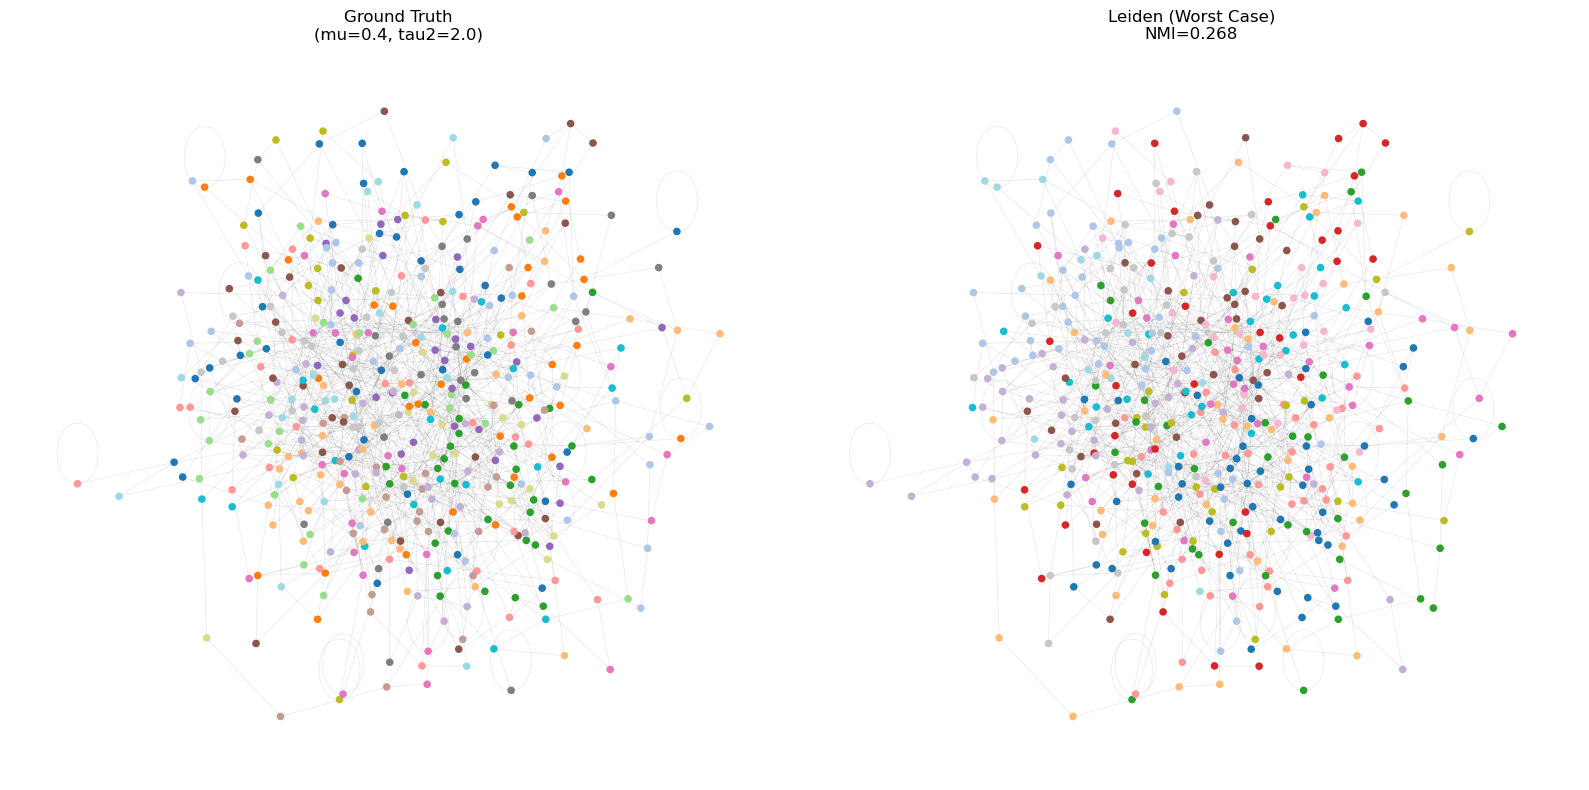

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Layout
pos_w = nx.spring_layout(G_w, seed=42)

# Ground truth colori
node_to_comm_gt = {}
for cid, community in enumerate(coms_w.communities):
    for node in community:
        node_to_comm_gt[node] = cid
colors_gt = [node_to_comm_gt[node] for node in G_w.nodes()]

# Leiden colori
node_to_comm_leiden = {}
for cid, community in enumerate(leiden_w.communities):
    for node in community:
        node_to_comm_leiden[node] = cid
colors_leiden = [node_to_comm_leiden[node] for node in G_w.nodes()]

# Plot side by side
plt.figure(figsize=(16, 8))

# ---- Ground truth ----
plt.subplot(1, 2, 1)
nx.draw_networkx_nodes(G_w, pos_w, node_size=20, node_color=colors_gt, cmap=plt.cm.tab20)
nx.draw_networkx_edges(G_w, pos_w, alpha=0.15, width=0.3)
plt.title(f"Ground Truth\n(mu={mu_worst}, tau2={tau2_worst})")
plt.axis("off")

# ---- Leiden ----
plt.subplot(1, 2, 2)
nx.draw_networkx_nodes(G_w, pos_w, node_size=20, node_color=colors_leiden, cmap=plt.cm.tab20)
nx.draw_networkx_edges(G_w, pos_w, alpha=0.15, width=0.3)
plt.title(f"Leiden (Worst Case)\nNMI={row['NMI']:.3f}")
plt.axis("off")

plt.tight_layout()
plt.show()


Plot che mostra gli errori di classificazione di Leiden 

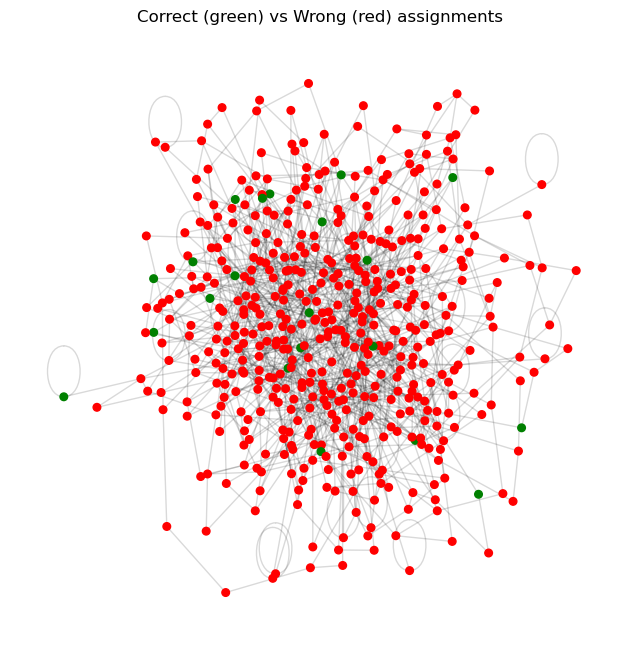

In [23]:
# Crea mappa nodo -> community GT
node_to_gt = {}
for cid, comm in enumerate(coms_w.communities):
    for n in comm:
        node_to_gt[n] = cid

# Crea mappa nodo -> community Leiden
node_to_lei = {}
for cid, comm in enumerate(leiden_w.communities):
    for n in comm:
        node_to_lei[n] = cid

# Colora: verde se giusto, rosso se sbagliato
colors_correct_wrong = [
    "green" if node_to_gt[n] == node_to_lei[n] else "red"
    for n in G_w.nodes()
]

plt.figure(figsize=(8,8))
nx.draw_networkx_nodes(G_w, pos_w, node_size=30, node_color=colors_correct_wrong)
nx.draw_networkx_edges(G_w, pos_w, alpha=0.15)
plt.title("Correct (green) vs Wrong (red) assignments")
plt.axis("off")
plt.show()


visualizzazione risultato migliore 

In [32]:
# Rigenero il grafo esattamente con quei parametri
G_w, coms_w = LFR(
    n=500,
    tau1=3,
    tau2=1.5,
    mu=0.20,
    average_degree=5,
    min_community=20,
    seed=42,
)

In [33]:
from cdlib import algorithms, evaluation

leiden_w = algorithms.leiden(G_w)

nmi = evaluation.normalized_mutual_information(leiden_w, coms_w).score
ari = evaluation.adjusted_rand_index(leiden_w, coms_w).score
mod = evaluation.newman_girvan_modularity(G_w, leiden_w).score

print("NMI:", nmi)
print("ARI:", ari)
print("Modularità:", mod)
print("GT communities:", len(coms_w.communities))
print("Leiden communities:", len(leiden_w.communities))


NMI: 0.8337451008242547
ARI: 0.747697152211436
Modularità: 0.7135725414358977
GT communities: 16
Leiden communities: 17


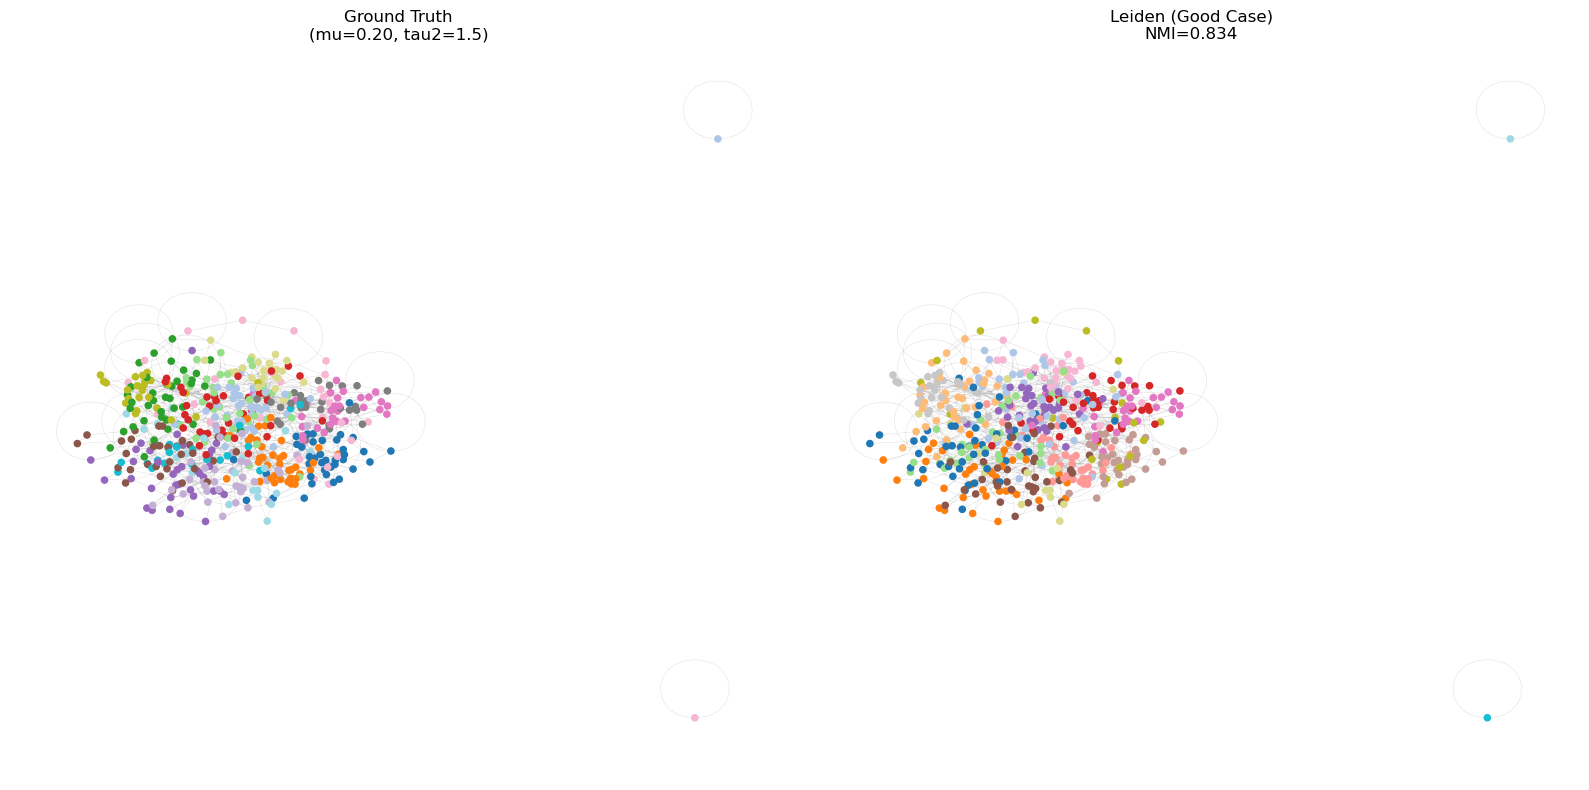

In [34]:
import matplotlib.pyplot as plt
import networkx as nx

pos_w = nx.spring_layout(G_w, seed=42)

# --- colori GT ---
node_to_comm_gt = {}
for cid, comm in enumerate(coms_w.communities):
    for n in comm:
        node_to_comm_gt[n] = cid
colors_gt = [node_to_comm_gt[n] for n in G_w.nodes()]

# --- colori Leiden ---
node_to_comm_leiden = {}
for cid, comm in enumerate(leiden_w.communities):
    for n in comm:
        node_to_comm_leiden[n] = cid
colors_leiden = [node_to_comm_leiden[n] for n in G_w.nodes()]

plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
nx.draw_networkx_nodes(G_w, pos_w, node_size=20, node_color=colors_gt, cmap=plt.cm.tab20)
nx.draw_networkx_edges(G_w, pos_w, alpha=0.15, width=0.3)
plt.title(f"Ground Truth\n(mu=0.20, tau2=1.5)")
plt.axis("off")

plt.subplot(1, 2, 2)
nx.draw_networkx_nodes(G_w, pos_w, node_size=20, node_color=colors_leiden, cmap=plt.cm.tab20)
nx.draw_networkx_edges(G_w, pos_w, alpha=0.15, width=0.3)
plt.title(f"Leiden (Good Case)\nNMI={nmi:.3f}")
plt.axis("off")

plt.tight_layout()
plt.show()


Fraction of correctly assigned nodes: 0.846


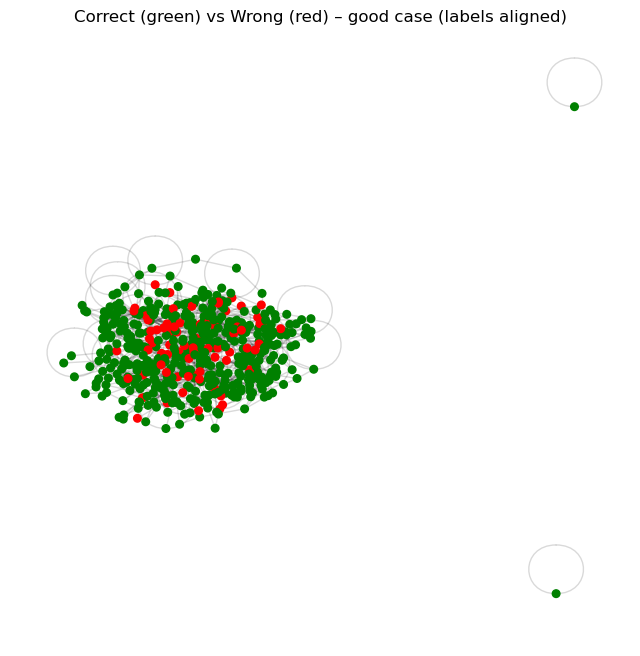

In [37]:
import numpy as np

gt_coms_list = coms_w.communities
lei_coms_list = leiden_w.communities

ng = len(gt_coms_list)
nl = len(lei_coms_list)

# 1) Matrice overlap GT x Leiden
overlap = np.zeros((ng, nl), dtype=int)

for i, gt_c in enumerate(gt_coms_list):
    gt_set = set(gt_c)
    for j, lei_c in enumerate(lei_coms_list):
        overlap[i, j] = len(gt_set & set(lei_c))

# 2) Per ogni community Leiden, scegli la GT migliore (massimo overlap)
lei_to_gt_map = {}
for j in range(nl):
    i_best = np.argmax(overlap[:, j])
    lei_to_gt_map[j] = i_best

# 3) Dizionari nodo -> label GT / Leiden_rimappata
node_to_gt = {}
for cid, comm in enumerate(gt_coms_list):
    for n in comm:
        node_to_gt[n] = cid

node_to_lei_mapped = {}
for j, comm in enumerate(lei_coms_list):
    mapped_label = lei_to_gt_map[j]
    for n in comm:
        node_to_lei_mapped[n] = mapped_label

# 4) Colori verde/rosso con etichette riallineate
colors_correct_wrong = [
    "green" if node_to_gt[n] == node_to_lei_mapped[n] else "red"
    for n in G_w.nodes()
]

# Percentuale di nodi corretti (solo per curiosità)
correct_frac = sum(
    1 for n in G_w.nodes() if node_to_gt[n] == node_to_lei_mapped[n]
) / G_w.number_of_nodes()
print("Fraction of correctly assigned nodes:", correct_frac)

import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(8, 8))
nx.draw_networkx_nodes(G_w, pos_w, node_size=30, node_color=colors_correct_wrong)
nx.draw_networkx_edges(G_w, pos_w, alpha=0.15)
plt.title("Correct (green) vs Wrong (red) – good case (labels aligned)")
plt.axis("off")
plt.show()



ESPERIMENTO CON COMUNITÀ + PICCOLE 

In [38]:
from cdlib.benchmark import LFR
from cdlib import algorithms, evaluation

G,coms = LFR(
    n=250,
    tau1=3,
    tau2=1.5,          # un po' più grande → community meno estremamente sbilanciate
    mu=0.1,
    average_degree=5,  # grado medio un po' più basso
    min_community=20,  # finestra community più larga
    tol=1e-5,          # più tolleranza
    max_iters=1000,    # più tentativi per trovare una partizione valida
    seed=42
)

print(G)                 # questo è un grafo NetworkX
gt_coms = coms.communities        # queste sono le community ground truth
print(coms.communities)
print("Numero di community ground truth:", len(gt_coms))

Graph with 250 nodes and 513 edges
[[128, 130, 131, 134, 137, 139, 142, 15, 144, 17, 146, 147, 27, 41, 42, 173, 182, 55, 58, 61, 66, 68, 197, 196, 199, 74, 205, 207, 87, 88, 94, 224, 227, 233, 108, 238, 114, 115, 242, 117, 247, 121, 122, 126], [132, 136, 8, 10, 140, 13, 16, 145, 20, 148, 22, 149, 186, 189, 65, 213, 85, 217, 90, 93, 222, 96, 226, 101, 231, 235, 236, 237, 241, 116, 119, 125], [1, 28, 36, 38, 167, 168, 44, 46, 175, 48, 174, 180, 181, 54, 52, 56, 188, 190, 70, 71, 200, 202, 75, 203, 78, 80, 91, 99, 229, 239, 240, 248], [193, 195, 135, 201, 76, 79, 81, 152, 154, 155, 156, 157, 219, 159, 221, 33, 162, 163, 34, 164, 166, 40, 232, 234, 107, 112, 178, 51, 53, 185, 62], [2, 3, 11, 12, 141, 209, 18, 210, 82, 212, 84, 214, 25, 218, 220, 158, 31, 161, 225, 35, 97, 100, 230, 102, 104, 106, 47, 179, 243, 244, 124], [0, 192, 133, 5, 7, 69, 204, 14, 143, 208, 19, 21, 23, 24, 29, 32, 37, 170, 172, 177, 49, 245, 246, 184, 57, 123, 60, 127], [64, 129, 4, 198, 73, 138, 77, 83, 150, 86, 215

In [39]:
from cdlib import algorithms, evaluation

# 1) Esegui Leiden sul grafo G
leiden_coms = algorithms.leiden(G)

print("Comunità trovate da Leiden:", len(leiden_coms.communities))
print("Esempio prime 3 community trovate:")
for i, c in enumerate(leiden_coms.communities[:3]):
    print(f"Community {i}: {len(c)} nodi")


Comunità trovate da Leiden: 8
Esempio prime 3 community trovate:
Community 0: 44 nodi
Community 1: 32 nodi
Community 2: 32 nodi


In [40]:
# coms = ground truth (oggetto Clustering)
# leiden_coms = partizione trovata da Leiden

nmi = evaluation.normalized_mutual_information(leiden_coms, coms)
ari = evaluation.adjusted_rand_index(leiden_coms, coms)
mod = evaluation.newman_girvan_modularity(G, leiden_coms)

print("NMI:", nmi.score)
print("ARI:", ari.score)
print("Modularità (Leiden):", mod.score)


NMI: 1.0
ARI: 1.0
Modularità (Leiden): 0.7946395662103058


In [41]:
import networkx as nx
import matplotlib.pyplot as plt

# usa il grafo G che hai già generato
pos = nx.spring_layout(G, seed=42)  # layout force-directed

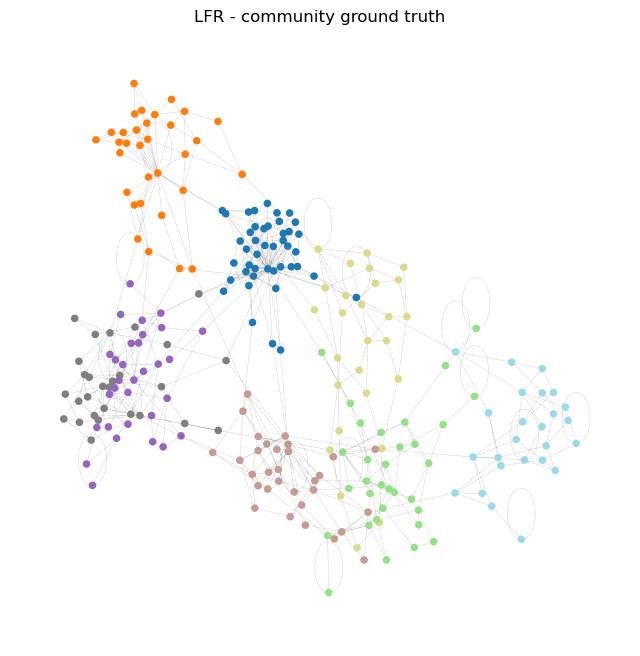

In [42]:
# Crea un dizionario nodo -> id_community ground truth
node_to_comm_gt = {}

for cid, community in enumerate(coms.communities):
    for node in community:
        node_to_comm_gt[node] = cid

# Lista dei colori per ogni nodo nell’ordine di G.nodes()
colors_gt = [node_to_comm_gt[node] for node in G.nodes()]

plt.figure(figsize=(8, 8))
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=20,
    node_color=colors_gt,
    cmap=plt.cm.tab20
)
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2,
    width=0.3
)
plt.title("LFR - community ground truth")
plt.axis("off")
plt.show()


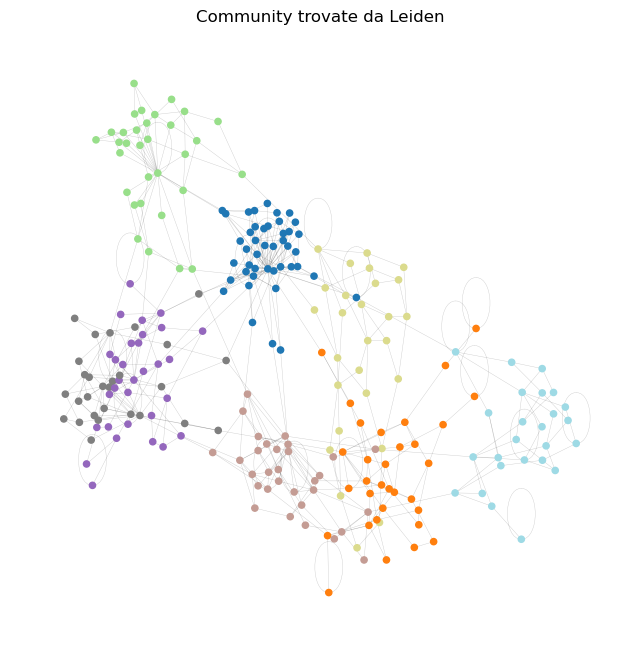

In [43]:
# Crea un dizionario nodo -> id_community Leiden
node_to_comm_leiden = {}

for cid, community in enumerate(leiden_coms.communities):
    for node in community:
        node_to_comm_leiden[node] = cid

colors_leiden = [node_to_comm_leiden[node] for node in G.nodes()]

plt.figure(figsize=(8, 8))
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=20,
    node_color=colors_leiden,
    cmap=plt.cm.tab20
)
nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2,
    width=0.3
)
plt.title("Community trovate da Leiden")
plt.axis("off")
plt.show()


Fraction of correctly assigned nodes: 1.0


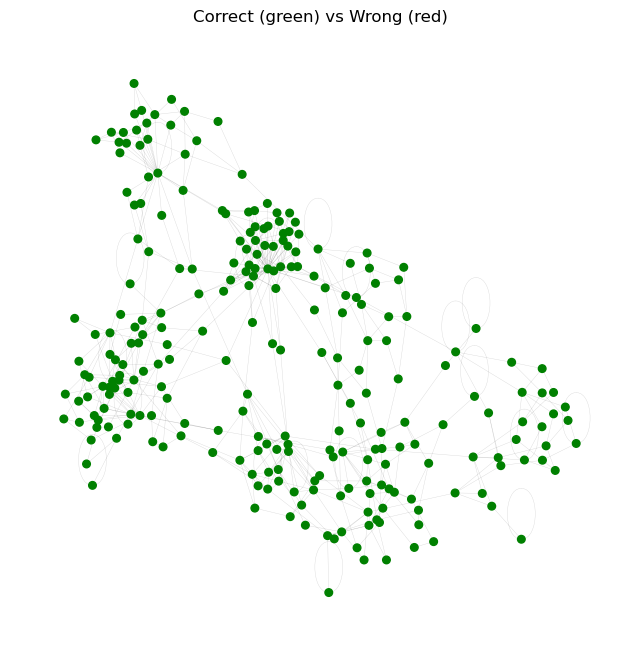

In [45]:
gt_coms_list = coms.communities
lei_coms_list = leiden_coms.communities

ng = len(gt_coms_list)
nl = len(lei_coms_list)

# 1) Matrice di overlap GT x Leiden
overlap = np.zeros((ng, nl), dtype=int)

for i, gt_c in enumerate(gt_coms_list):
    gt_set = set(gt_c)
    for j, lei_c in enumerate(lei_coms_list):
        overlap[i, j] = len(gt_set & set(lei_c))

# 2) Per ogni comunità Leiden scegli la community GT più simile
lei_to_gt_map = {}
for j in range(nl):
    i_best = np.argmax(overlap[:, j])
    lei_to_gt_map[j] = i_best

# 3) Dizionari nodo -> label GT / label Leiden (rimappata)
node_to_gt = {}
for cid, comm in enumerate(gt_coms_list):
    for n in comm:
        node_to_gt[n] = cid

node_to_lei_mapped = {}
for j, comm in enumerate(lei_coms_list):
    mapped_label = lei_to_gt_map[j]
    for n in comm:
        node_to_lei_mapped[n] = mapped_label

# 4) Colori: verde se giusto, rosso se sbagliato
colors_correct_wrong = [
    "green" if node_to_gt[n] == node_to_lei_mapped[n] else "red"
    for n in G.nodes()
]

# Percentuale di nodi corretti (giusto per info)
correct_frac = sum(
    1 for n in G.nodes() if node_to_gt[n] == node_to_lei_mapped[n]
) / G.number_of_nodes()
print("Fraction of correctly assigned nodes:", correct_frac)

# 5) Plot
plt.figure(figsize=(8, 8))
nx.draw_networkx_nodes(G, pos, node_size=30, node_color=colors_correct_wrong)
nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.3)
plt.title("Correct (green) vs Wrong (red)")
plt.axis("off")
plt.show()
